In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

## Topologia General

In [2]:
df_results=pd.read_csv('csv/resultados_topologia_general.csv')

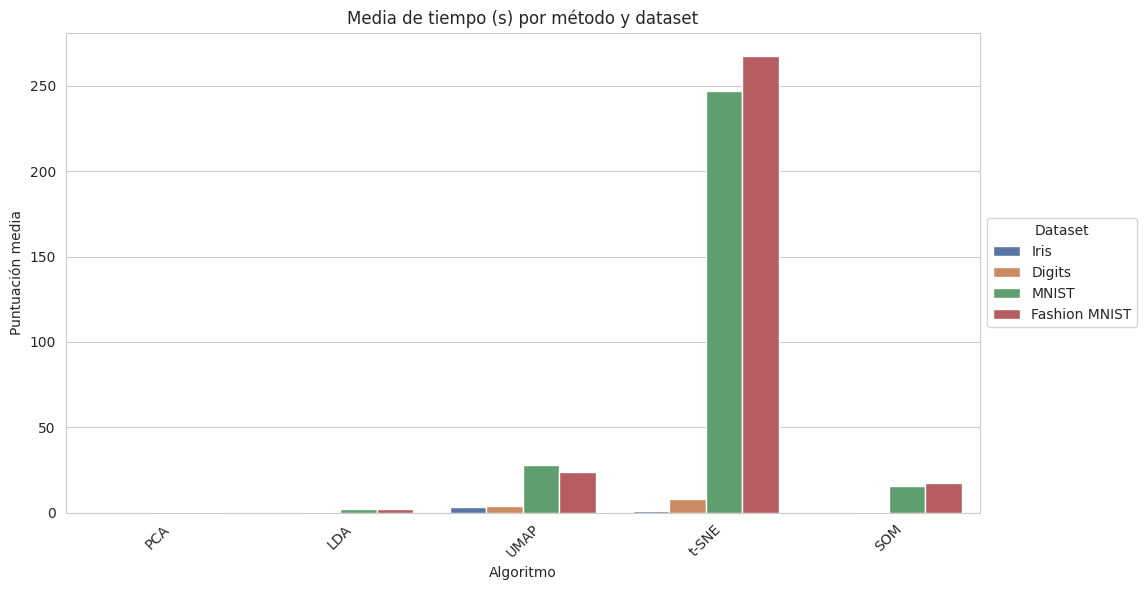

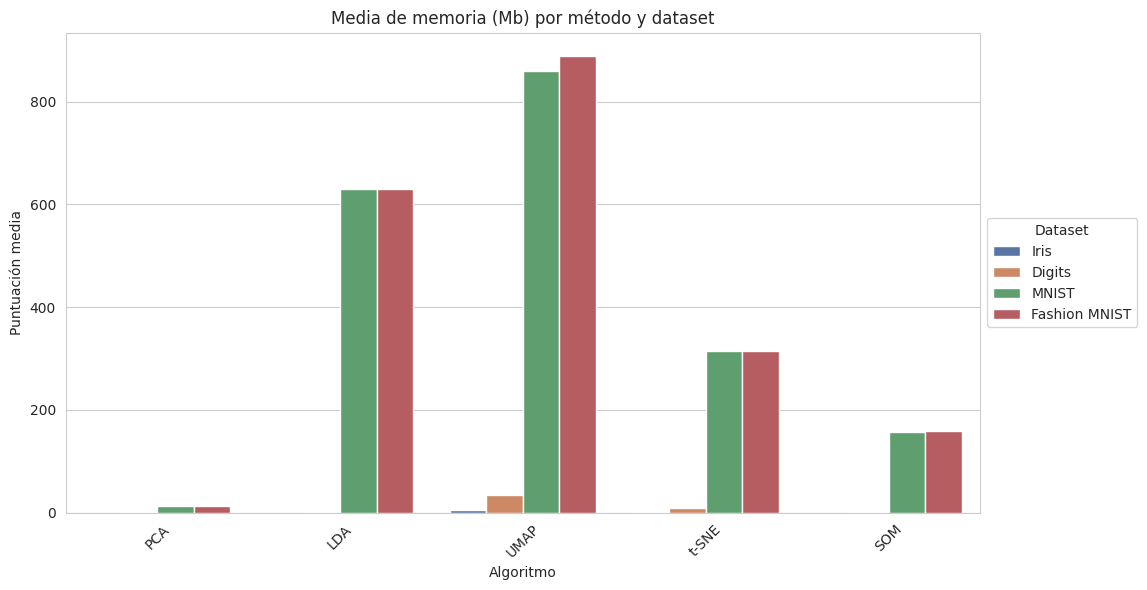

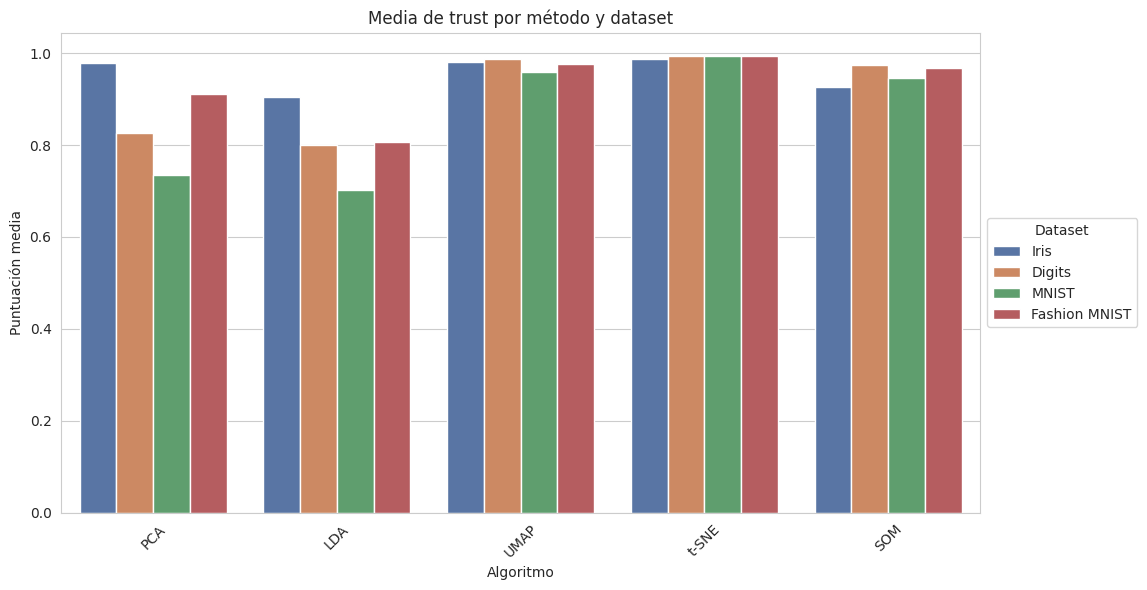

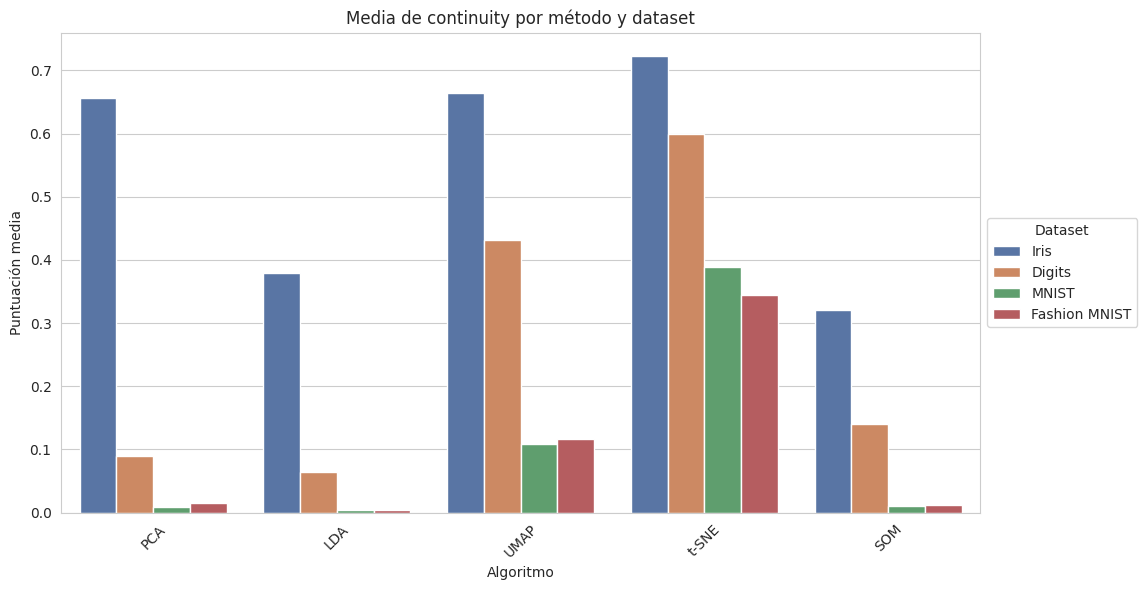

In [5]:
metricas = df_results['index'].unique()
sns.set_style('whitegrid')
sns.set_palette('deep', n_colors=4)
for metrica in metricas:
    df_metrica = df_results[df_results['index'] == metrica]
    
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(data=df_metrica, x='method', y='mean', hue='dataset')
    
    plt.title(f'Media de {metrica} por método y dataset')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.xlabel("Algoritmo")
    plt.ylabel("Puntuación media")
    # Mover la leyenda fuera de la gráfica
    ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), title='Dataset')
    plt.savefig(f"imgs/general_{metrica}.png", dpi= 300, bbox_inches='tight')
    plt.show()

## Topologia SOM vs MiniSOM

In [6]:
df_results=pd.read_csv('csv/resultados_topologia_minisom.csv')

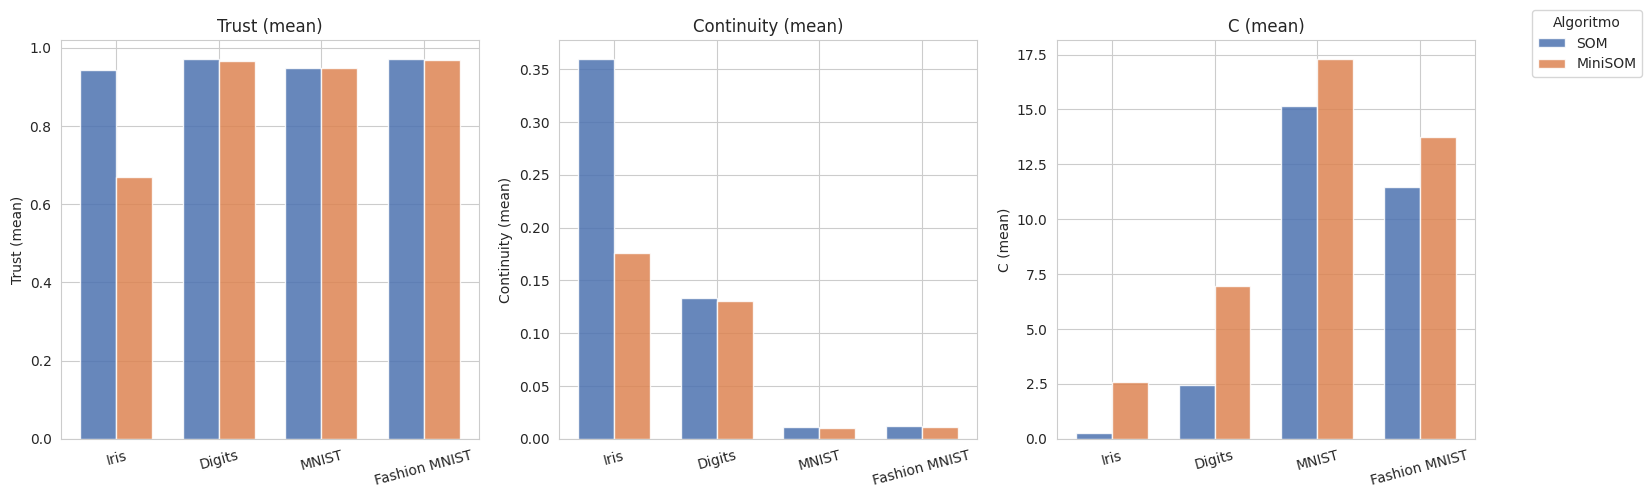

In [14]:

metrics = ['Trust (mean)', 'Continuity (mean)', 'C (mean)']
datasets = df_results['Dataset'].unique()
methods = df_results['Method'].unique()

# Posiciones para barras agrupadas
x = np.arange(len(datasets))  # el eje x será cada dataset
width = 0.35  # ancho de cada barra
sns.set_style('whitegrid')
sns.set_palette('deep', n_colors=4)
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True)


# Guardamos los handles de las barras para la leyenda
handles = []
labels = []

for idx, metric in enumerate(metrics):
    for i, method in enumerate(methods):
        values = []
        for dataset in datasets:
            val = df_results[(df_results['Dataset'] == dataset) & (df_results['Method'] == method)][metric].values[0]
            values.append(val)
        bars = axes[idx].bar(x + (i-0.5)*width, values, width, label=method, alpha=0.85)
        if idx == 0:
            handles.append(bars[0])
            labels.append(method)
    axes[idx].set_title(metric)
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(datasets, rotation=15)
    axes[idx].set_ylabel(metric)

# Poner leyenda global, usando los handles y labels recogidos
fig.legend(handles, labels, title="Algoritmo", bbox_to_anchor=(1.02,1), loc='upper left')
fig.tight_layout()
plt.savefig("imgs/top_minisom.png",dpi=300, bbox_inches='tight')
plt.show()